In [1]:
# Matches UAV Trajectories, Image Timing Files, and Weather Station Data
# PBB 3/31/23

# UPDATES:
# 4/3/23
# All thermal landscapes projects run. 
# edits made to classes .py
# looks good!

# 3/31/23
# - TBD -
# Find image timing files from other sites and run through
# then bring into R, filter with seperate script for imporant images for thermal landscapes
# and add air temp, img time, and RH into the GAM models
# Also, fix up your Classes.py here and elsewhere with changes to datetime and GPS time functions
# - To Check - 
# NOTE: Check possible issues with GPS Time and local time
# especially when converting image times back to local times...
# CHECK THIS LINE and below
# t = GPSTime.from_datetime(dt).time_of_week

import sys
sys.path.append('/n/home02/pbb/scripts/halo-metadata-server/')
from Classes import Project
import pandas as pd
from pathlib import Path
import ipywidgets
import glob
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime, timedelta, timezone
import pytz
from gps_time import GPSTime
import seaborn as sns


# Set the seaborn plot theme to default
# incorporates grey grid into background of figures
custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(font_scale=1.1, style="ticks", rc=custom_params)

# set working directory
wd = '/n/home02/pbb/scripts/halo-metadata-server/ThermalLandscapes'

In [21]:
# Read in and Process Weather Data File (for all sites)

# Weather data file (all sites)
weatherf = f'{wd}/data/in/WeatherData_ThermalLandscapes_curated.csv'
weatherdf = pd.read_csv(weatherf)

# Convert weatherdf times to gps times 
# So that you can interpolate temp/RH values
# apply to dataframe
weatherdf['DateTime'] = weatherdf.apply(lambda x: datetime.strptime(f'{x.Date} {x.Time}',
                                                                    '%m/%d/%Y %H:%M'),
                                                                    axis=1)
# Using GPSTime module here to convert from local time to GPS Time of week
weatherdf['GPSTime'] = weatherdf.DateTime.apply(lambda x: GPSTime.from_datetime(x).time_of_week)

# Rewrite the time column to be consistent with the imagetime_df Times, 
# so that they plot on top of each other in matplotlib
weatherdf['Time'] = weatherdf.DateTime.apply(lambda x: x.strftime("%H:%M:%S"))

# Save it!
weatherdf.to_csv(f'{wd}/data/in/WeatherDataFrame_DateTime.csv')
weatherdf.Site.unique()

array(['Nkhulu', 'Buffalo Camp', 'Hlangwine', 'Makhohlola', 'Roan Camp',
       'Letaba'], dtype=object)

In [22]:
# Define Project, Trajectories, and Image Timing inputs

# list of project directories to loop through
# - Completed as of 4/3/23 - 
projdirs = ['/n/davies_lab/Lab/data/processed/Africa/Kruger/2020/2020_01-02/20200116_NkuluEP',
            '/n/holystore01/LABS/davies_lab/Lab/data/processed/Africa/Kruger/2020/2020_12/RoanCamp',
            '/n/holystore01/LABS/davies_lab/Lab/data/processed/Africa/Kruger/2020/2020_12/LetabaExclosure',
            '/n/holystore01/LABS/davies_lab/Lab/data/processed/Africa/Kruger/2020/2020_01-02/20200124-081112_MakhohlolaEP',
            '/n/holystore01/LABS/davies_lab/Lab/data/processed/Africa/Kruger/2020/2020_01-02/20200121_BuffaloCamp/AltitudeStudy/20200121-064054_BuffaloCamp100m',
            '/n/davies_lab/Lab/data/processed/Africa/Kruger/2020/2020_01-02/20200122_HlangwineEP']
# -


# paths to the image timing (.txt) files you want to use 
# needs to match the order of the projects above
# Completed - 
imgtimefiles = ['/n/davies_lab/Lab/data/processed/Africa/Kruger/2020/2020_01-02/20200116_NkuluEP/Terrasolid/Terraphoto/thermal/cam1_multiband_allflights_NewImgTiming.txt',
                '/n/holystore01/LABS/davies_lab/Lab/data/processed/Africa/Kruger/2020/2020_12/RoanCamp/Terrasolid/Terraphoto/thermal/RoanCamp_thermal_image_timing.txt',
                '/n/holystore01/LABS/davies_lab/Lab/data/processed/Africa/Kruger/2020/2020_12/LetabaExclosure/Terrasolid/Terraphoto/thermal/Letaba_thermal_image_timing.txt',
                '/n/holystore01/LABS/davies_lab/Lab/data/processed/Africa/Kruger/2020/2020_01-02/20200124-081112_MakhohlolaEP/Terrasolid/Terraphoto/thermal/thermal_imagetiming.txt',
                '/n/holystore01/LABS/davies_lab/Lab/data/processed/Africa/Kruger/2020/2020_01-02/20200121_BuffaloCamp/AltitudeStudy/20200121-064054_BuffaloCamp100m/Terrasolid/Terraphoto/thermal/thermaltiming.txt',
                '/n/davies_lab/Lab/data/processed/Africa/Kruger/2020/2020_01-02/20200122_HlangwineEP/Terrasolid/Terraphoto/thermal/cam1_multiband_NewImgTiming.txt']

# list of sites (how they are spelled in the weather data file)
# Completed - 
sites = ['Nkhulu', 'Roan Camp','Letaba', 'Makhohlola','Buffalo Camp', 'Hlangwine']


In [23]:
# Functions
def convertGPSTimetoLocalTime(time, day, month, year, offset=2):
    # offset is offset from GTCT time (SA is +2)
    # force to int for use in datetime 
    day = int(day)
    month = int(month)
    year = int(year)

    # Make datetime object of input GPStime
    dt = datetime(day=day, month=month, year=year, tzinfo=timezone.utc)

    # Start the time of that week (since GPS TOW counts seconds since the start of the week)
    # Subtract number of days  isoweekday() of base station date to count back to the beg. of week
    start_of_week = datetime(year = year,
                             day = day,
                             month = month) - timedelta(days=dt.isoweekday())

    # Use datetime's timedelta to add the GPS TOW seconds to the start of the week datetime
    curr_dt = start_of_week + timedelta(seconds=time)
    
    # Convert to local time using offset from gtc
    curr_dt = curr_dt + timedelta(hours=offset)

    # Set the current date and time! Easy.
    date = curr_dt.strftime("%Y-%m-%d")
    UTC = curr_dt.strftime("%H:%M:%S")
                             
    return curr_dt

/tmp/ipykernel_165558/4166402584.py:139: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)
/tmp/ipykernel_165558/4166402584.py:149: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90)


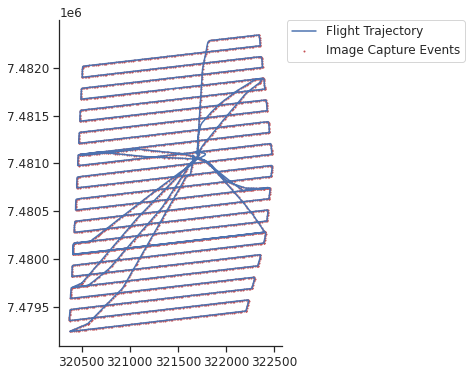

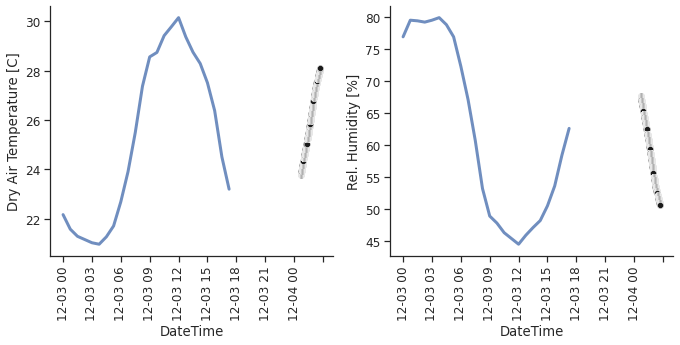

In [67]:
for pdir, itf, site in zip(projdirs, imgtimefiles, sites):
# Just run roan camp
# for pdir, itf, site in zip([projdirs[1]], [imgtimefiles[1]], [sites[1]]):

    # make a new project (False), or load an existing (True)
    proj = Project(pdir, loadfromjson=True)
    
    proj.Trajectory.getUTMtraj()
    
    UTMTraj = pd.DataFrame({'GPSTime':proj.Trajectory.alltrajs['time'],
                            'Lat':proj.Trajectory.alltrajs['latitude'],
                            'Lon':proj.Trajectory.alltrajs['longitude'],
                            'Easting':proj.Trajectory.alltrajs_utm['easting'],
                            'Northing':proj.Trajectory.alltrajs_utm['northing'],
                            'Altitude':proj.Trajectory.alltrajs['altitude'],
                            'Roll':proj.Trajectory.alltrajs['roll'],
                            'Pitch':proj.Trajectory.alltrajs['pitch'],
                            'Heading':proj.Trajectory.alltrajs['platform_heading']})

    # For some reason, at Nkuhlu, some (840) of the trajectory values are really weird.
    # If you cut them, looks normal. Most likely there's an errant sbet file causing this. 
    # sum(UTMTraj.Lat >-5) # this = 840
    # This should fix it 
    UTMTraj = UTMTraj.loc[UTMTraj.Lat < -5]

    UTMTraj.sort_values(by='GPSTime', ascending=True, inplace=True, ignore_index=True)
    
    # Save Trajectory for later use
    UTMTraj.to_csv(f'{proj.projdir}/docs/{proj.date}_{proj.projstr}_Trajectory_EPSG{proj.epsg}.csv')
    UTMTraj.to_csv(f'{wd}/data/in/Trajectories/{proj.date}_{proj.projstr}_Trajectory_EPSG{proj.epsg}.csv')
    
    # Read in image timing file
    it = pd.read_csv(itf, sep=' ', header=None,
                     names=['GPSTime', 'Imagef'])
    
    # get position (easting, northing, alt.) of each image, by linear interpolation
    
    North_interp = []
    East_interp = [] 
    Alt_interp = []
    
    # Comparing trajectory times and image times (which should both be in relation to UTC)
    for t in it.GPSTime:

        # Index of time in trajectory closest to the image capture
        idx = np.argmin(np.abs(UTMTraj.GPSTime - t))

        # Get the interpolated position
        # Using the index 
        North_interp.append(np.interp(t,
                                     UTMTraj.GPSTime[(idx-1):idx:(idx+1)],
                                     UTMTraj.Northing[(idx-1):idx:(idx+1)]))

        East_interp.append(np.interp(t,
                                 UTMTraj.GPSTime[(idx-1):idx:(idx+1)],
                                 UTMTraj.Easting[(idx-1):idx:(idx+1)])) 

        Alt_interp.append(np.interp(t,
                             UTMTraj.GPSTime[(idx-1):idx:(idx+1)],
                             UTMTraj.Altitude[(idx-1):idx:(idx+1)]))
 
    
    # Make a plot of the trajectory for reference
    fig1, ax1 = plt.subplots(figsize=(4, 6))
    ax1.plot(UTMTraj.Easting, UTMTraj.Northing, label='Flight Trajectory')
    ax1.scatter(East_interp, North_interp, c='r', s=1, label='Image Capture Events')
    plt.axis('equal')
    ax1.legend()
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', borderaxespad=0)
    
    fig1.savefig(f'{wd}/figs/Trajectories/{proj.date}_{proj.projstr}_Trajectory.png', dpi=300)
    
           
    # Make an image trajectory df
    imgtime_df = it.assign(Northing=North_interp, 
                           Easting=East_interp,
                           Altitude=Alt_interp,
                           Site=proj.projstr,
                           Date=proj.date)
    
    # Compute local time of each image 
    d = proj.date.split('-')[2]
    m = proj.date.split('-')[1]
    y = proj.date.split('-')[0]
    imgtime_df['DateTime'] = imgtime_df.GPSTime.apply(lambda t: convertGPSTimetoLocalTime(t, day=d, month=m, year=y, offset=2))
    imgtime_df['Time'] = imgtime_df.GPSTime.apply(lambda t: convertGPSTimetoLocalTime(t, day=d, month=m, year=y, offset=2).strftime("%H:%M:%S"))
    
    # # # Connect Images to Weather Data and Trajectory
    # Subset to current project site
    # note: site names might be slightly different/mispelled... Fix that someday
    weatherdf_site = weatherdf.loc[weatherdf.Site == site]
    
    # Add in weather information by interpolation
    RH_interp = []
    Temp_interp = []
    
    # comparing weather times (local time) and image times (UTC)
    # so have to use GPSTime to convert times back to gps time of week
    for dt in imgtime_df.DateTime:
        
        t = GPSTime.from_datetime(dt).time_of_week
        
        # NOTE 4/4/23
        # Added a hard-coded fix for Roan Camp
        # The weather data is 1 day (24 hrs, 86400 seconds) before, on dec 3rd instead of dec 4
        # Assuming the temp and RH values are similar both days
        # We can still interpolate
        if site == 'Roan Camp':
            t = t - 86400

        # Index of time in trajectory closest to the image capture
        idx = np.argmin(np.abs(weatherdf_site.GPSTime - t))

        # Get the interpolated weather values
        RH_interp.append(np.interp(t,
                                   weatherdf_site.GPSTime[(idx-3):(idx+3)],
                                   weatherdf_site.Rhum_Perc[(idx-3):(idx+3)]))

        Temp_interp.append(np.interp(t,
                                     weatherdf_site.GPSTime[(idx-3):(idx+3)],
                                     weatherdf_site.Tdry_C[(idx-3):(idx+3)])) 
    
    # Add weather data
    imgtime_df['RH'] = RH_interp
    imgtime_df['AirTemp'] = Temp_interp
    
    # Save it
    imgtime_df.to_csv(f'{wd}/data/in/ImageTrajectories/{proj.projstr}_ImageTrajectory_withWeather.csv')

    # Plot image captures and weather data
    fig2, (ax1, ax2) = plt.subplots(1,2, figsize = (10, 5))
    
    # Air Temp
    sns.lineplot(data=weatherdf_site,
                 x='DateTime', y='Tdry_C',
                 lw=3, alpha=0.8, ax=ax1)

    ax1.set_ylabel('Dry Air Temperature [C]')
    fig2.tight_layout()
    ax1.set_xticklabels(ax1.get_xticklabels(), rotation=90)
    sns.scatterplot(data = imgtime_df, x='DateTime', y='AirTemp', color='k', ax=ax1)
    
    # Rel Humidity
    sns.lineplot(data=weatherdf_site,
                 x='DateTime', y='Rhum_Perc',
                 lw=3, alpha=0.8, ax=ax2)

    ax2.set_ylabel('Rel. Humidity [%]')
    fig2.tight_layout()
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=90)
    sns.scatterplot(data = imgtime_df, x='DateTime', y='RH', color='k', ax=ax2)
    
    fig2.savefig(f'{wd}/figs/WeatherPlots/{proj.date}_{proj.projstr}_WeatherPlotwithImageEvents.png', dpi=300)

In [68]:
# Last, Combine all the files together for easy loading in R
df_list = []

for p in projdirs:
# for p in [projdirs[1]]:
    
    proj = Project(p, loadfromjson=True)
    
    df = pd.read_csv(f'{wd}/data/in/ImageTrajectories/{proj.projstr}_ImageTrajectory_withWeather.csv')
    
    df.drop('Unnamed: 0', axis=1, inplace=True)

    df_list.append(df)

# stick list together
IT_df = pd.concat(df_list)

# save
IT_df.to_csv(f'{wd}/data/in/ImageTrajectories/AllSites_ImageTrajectory_withWeather.csv', index=False)